# GRU — Búsqueda de hiperparámetros · input=5, output=1

Notebook dedicado a encontrar los mejores hiperparámetros de la GRU para la combinación de ventana **input=5 días de historia → output=1 día de predicción**.

La búsqueda sigue la misma estructura de dos etapas que `rnn-gru.ipynb`:

1. **Etapa 1 — Arquitectura**: `gru_layers × units × dropout` con lr=1e-3 y batch=128 fijos.
2. **Etapa 2 — Entrenamiento**: `learning_rate × batch_size` con la arquitectura ganadora.

Finalmente se entrena el modelo ganador completo y se compara su MAE test contra la GRU base del grid de ventanas y la regresión lineal.

In [1]:
import sys
import itertools
import mlflow
from pathlib import Path

# Busca util.py subiendo niveles desde el directorio actual
_here = Path.cwd()
PROJECT_ROOT = next(
    p for p in [_here, _here.parent, _here.parent.parent, _here.parent.parent.parent]
    if (p / 'util.py').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'model' / 'mlflow.db'}")

EXPERIMENT_NAME = "Red_Neuronal_Recurrente_GRU"
mlflow.set_experiment(EXPERIMENT_NAME)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Input
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error

from util import get_train_test, RANDOM_SEED, compare_to_benchmark, plot_benchmark_comparison, plot_training_curve, load_benchmark

np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carga de datos

Ventana fija: **input=5 días, output=1 día**.

Se mantiene el tensor 3D `[samples, timesteps, features]` que espera la GRU. El split de validación (10% del train) se extrae de los últimos ejemplos para preservar el orden temporal.

In [2]:
def load_seq_data(input_window_size, output_window_size):
    """Devuelve datos con shape 3D [samples, timesteps, features] para GRU."""
    d = get_train_test(input_window_size=input_window_size, output_window_size=output_window_size)

    X_train = d.X_train
    X_test  = d.X_test
    y_train = d.y_train
    y_test  = d.y_test

    val_size = int(0.10 * X_train.shape[0])
    X_val   = X_train[-val_size:]
    y_val   = y_train[-val_size:]
    X_train = X_train[:-val_size]
    y_train = y_train[:-val_size]

    return X_train, y_train, X_val, y_val, X_test, y_test


INPUT_W, OUTPUT_W = 5, 1

X_tr, y_tr, X_val, y_val, X_te, y_te = load_seq_data(INPUT_W, OUTPUT_W)

print(f"Ventana fija: input={INPUT_W}, output={OUTPUT_W}")
print(f"X_tr:  {X_tr.shape}   y_tr:  {y_tr.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")
print(f"X_te:  {X_te.shape}   y_te:  {y_te.shape}")

Ventana fija: input=5, output=1
X_tr:  (13106, 5, 23)   y_tr:  (13106, 23)
X_val: (1456, 5, 23)  y_val: (1456, 23)
X_te:  (1618, 5, 23)   y_te:  (1618, 23)


## Funciones auxiliares

`build_gru` construye una GRU apilada con N capas recurrentes. Las capas intermedias usan `return_sequences=True` para encadenar la secuencia; solo la última devuelve el estado oculto final.

`fit_eval` entrena con `EarlyStopping` y devuelve los MAE de train, val y test.

In [3]:
def build_gru(gru_layers: int, units: int, dropout: float, lr: float = 1e-3):
    keras.utils.set_random_seed(RANDOM_SEED)
    m = Sequential()
    m.add(Input(shape=(X_tr.shape[1], X_tr.shape[2])))
    for i in range(gru_layers):
        return_seq = (i < gru_layers - 1)
        m.add(GRU(units, return_sequences=return_seq, dropout=dropout))
    m.add(Dense(y_tr.shape[1]))
    m.compile(loss="mean_absolute_error", optimizer=Adam(learning_rate=lr))
    return m


def fit_eval(model, batch_size: int = 128, epochs: int = 200, patience: int = 10, verbose: int = 0):
    """Entrena con EarlyStopping y devuelve MAE_train, MAE_val, MAE_test, history."""
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    h = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose,
    )
    mae_tr  = mean_absolute_error(y_tr,  model.predict(X_tr,  verbose=0))
    mae_val = mean_absolute_error(y_val, model.predict(X_val, verbose=0))
    mae_te  = mean_absolute_error(y_te,  model.predict(X_te,  verbose=0))
    return mae_tr, mae_val, mae_te, h

## Etapa 1 — Arquitectura

12 combinaciones: `gru_layers ∈ {1, 2}` · `units ∈ {32, 64, 128}` · `dropout ∈ {0.0, 0.2}`.

Parámetros de entrenamiento fijos: `lr=1e-3`, `batch=128`, `patience=10`, `max_epochs=200`.

La selección se hace con **MAE de validación**. El test no se toca durante la búsqueda.

In [4]:
arch_grid = list(itertools.product([1, 2], [32, 64, 128], [0.0, 0.2]))

results_arch = []
batch_size_arch = 128

for ll, u, dr in arch_grid:
    run_name = f"{EXPERIMENT_NAME}_arch_layers{ll}_units{u}_drop{dr}_input{INPUT_W}_output{OUTPUT_W}"
    existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing_runs.empty:
        mlflow.delete_run(existing_runs.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_gru(ll, u, dr, lr=1e-3)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=batch_size_arch)

        for epoch, (train_loss, val_loss) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss",   val_loss,   step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type",         "GRU")
        mlflow.log_param("gru_layers",         ll)
        mlflow.log_param("units",              u)
        mlflow.log_param("dropout",            dr)
        mlflow.log_param("learning_rate",      1e-3)
        mlflow.log_param("batch_size",         batch_size_arch)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features",       X_tr.shape[2])
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="gru_model")

        results_arch.append({
            "gru_layers": ll, "units": u, "dropout": dr,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]), "n_params": model.count_params(),
        })
        print(f"layers={ll} units={u:>3} dropout={dr}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_arch_df = pd.DataFrame(results_arch).sort_values("MAE_val").reset_index(drop=True)
results_arch_df.head(12)

2026/05/02 12:25:42 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 units= 32 dropout=0.0  ->  MAE val=0.009078 | train=0.011814 | test=0.012286 | epochs= 33


2026/05/02 12:25:49 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 units= 32 dropout=0.2  ->  MAE val=0.009068 | train=0.011830 | test=0.012275 | epochs= 24


2026/05/02 12:25:57 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

2026/05/02 12:27:36 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=2 units=128 dropout=0.0  ->  MAE val=0.009071 | train=0.011812 | test=0.012287 | epochs= 29


2026/05/02 12:27:57 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=2 units=128 dropout=0.2  ->  MAE val=0.009056 | train=0.011822 | test=0.012270 | epochs= 34


,gru_layers,units,dropout,MAE_train,MAE_val,MAE_test,epochs,n_params
0,2,32,0.2,0.011817,0.009053,0.012258,36,12567
1,2,64,0.2,0.011825,0.009056,0.012264,31,43543
2,2,128,0.2,0.011822,0.009056,0.012270,34,160791
3,1,32,0.2,0.011830,0.009068,0.012275,24,6231
4,2,32,0.0,0.011840,0.009069,0.012265,20,12567
5,1,64,0.2,0.011831,0.009070,0.012287,24,18583
6,2,128,0.0,0.011812,0.009071,0.012287,29,160791
7,2,64,0.0,0.011812,0.009075,0.012286,34,43543
8,1,32,0.0,0.011814,0.009078,0.012286,33,6231
9,1,128,0.2,0.011825,0.009079,0.012294,24,61719


### Visualización — top-10 configuraciones arquitectónicas

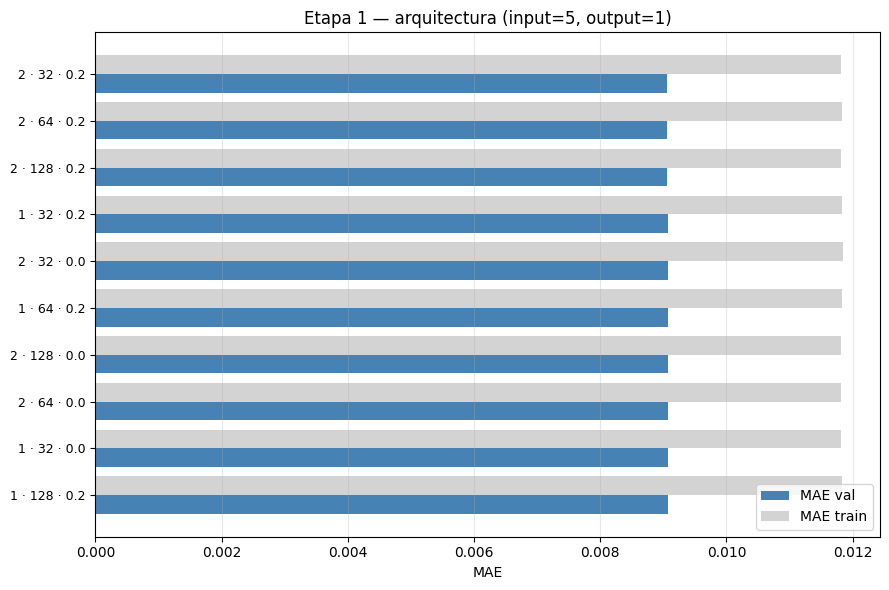

In [5]:
def plot_top(ax, df, label_cols, title, top=10):
    top_df = df.head(top).iloc[::-1]
    labels = top_df[label_cols].astype(str).agg(" · ".join, axis=1)
    ypos = np.arange(len(top_df))
    ax.barh(ypos - 0.2, top_df["MAE_val"],   height=0.4, label="MAE val",   color="steelblue")
    ax.barh(ypos + 0.2, top_df["MAE_train"], height=0.4, label="MAE train", color="lightgray")
    ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("MAE"); ax.set_title(title)
    ax.legend(loc="lower right"); ax.grid(True, axis="x", alpha=0.3)

fig, ax = plt.subplots(figsize=(9, 6))
plot_top(ax, results_arch_df, ["gru_layers", "units", "dropout"],
         f"Etapa 1 — arquitectura (input={INPUT_W}, output={OUTPUT_W})")
plt.tight_layout()
plt.show()

## Etapa 2 — Entrenamiento

Fijamos la **arquitectura ganadora** de la etapa 1 y barremos:
- `learning_rate ∈ {1e-2, 1e-3, 1e-4}`
- `batch_size ∈ {64, 128, 256}`

9 combinaciones en total. Mismo criterio: selección por **MAE de validación**.

In [6]:
best_arch = results_arch_df.iloc[0]
print(f"Mejor arquitectura: layers={int(best_arch.gru_layers)}  units={int(best_arch.units)}  dropout={best_arch.dropout}")
print(f"  MAE val = {best_arch.MAE_val:.6f}")

train_grid = list(itertools.product([1e-2, 1e-3, 1e-4], [64, 128, 256]))

results_train = []
for lr, bs in train_grid:
    run_name = f"{EXPERIMENT_NAME}_train_lr{lr:.0e}_batch{bs}_input{INPUT_W}_output{OUTPUT_W}"
    existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing_runs.empty:
        mlflow.delete_run(existing_runs.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_gru(
            int(best_arch.gru_layers),
            int(best_arch.units),
            float(best_arch.dropout),
            lr=lr,
        )
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=bs)

        for epoch, (train_loss, val_loss) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss",   val_loss,   step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type",         "GRU")
        mlflow.log_param("gru_layers",         int(best_arch.gru_layers))
        mlflow.log_param("units",              int(best_arch.units))
        mlflow.log_param("dropout",            float(best_arch.dropout))
        mlflow.log_param("learning_rate",      lr)
        mlflow.log_param("batch_size",         bs)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features",       X_tr.shape[2])
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="gru_model")

        results_train.append({
            "learning_rate": lr, "batch_size": bs,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]),
        })
        print(f"lr={lr:.0e} batch={bs:>3}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_train_df = pd.DataFrame(results_train).sort_values("MAE_val").reset_index(drop=True)
results_train_df

Mejor arquitectura: layers=2  units=32  dropout=0.2
  MAE val = 0.009053


2026/05/02 12:28:58 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch= 64  ->  MAE val=0.009278 | train=0.012103 | test=0.012434 | epochs= 19


2026/05/02 12:29:06 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch=128  ->  MAE val=0.009222 | train=0.012024 | test=0.012384 | epochs= 16


...

2026/05/02 12:30:08 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=128  ->  MAE val=0.009042 | train=0.011840 | test=0.012246 | epochs= 29


2026/05/02 12:30:19 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=256  ->  MAE val=0.009039 | train=0.011837 | test=0.012244 | epochs= 46


,learning_rate,batch_size,MAE_train,MAE_val,MAE_test,epochs
0,0.0001,256,0.011837,0.009039,0.012244,46
1,0.0001,64,0.011829,0.009041,0.012244,35
2,0.0001,128,0.011840,0.009042,0.012246,29
3,0.0010,256,0.011834,0.009050,0.012247,27
4,0.0010,128,0.011817,0.009053,0.012258,36
5,0.0010,64,0.011912,0.009075,0.012276,14
6,0.0100,256,0.011964,0.009153,0.012310,19
7,0.0100,128,0.012024,0.009222,0.012384,16
8,0.0100,64,0.012103,0.009278,0.012434,19


### Visualización — top configuraciones de entrenamiento

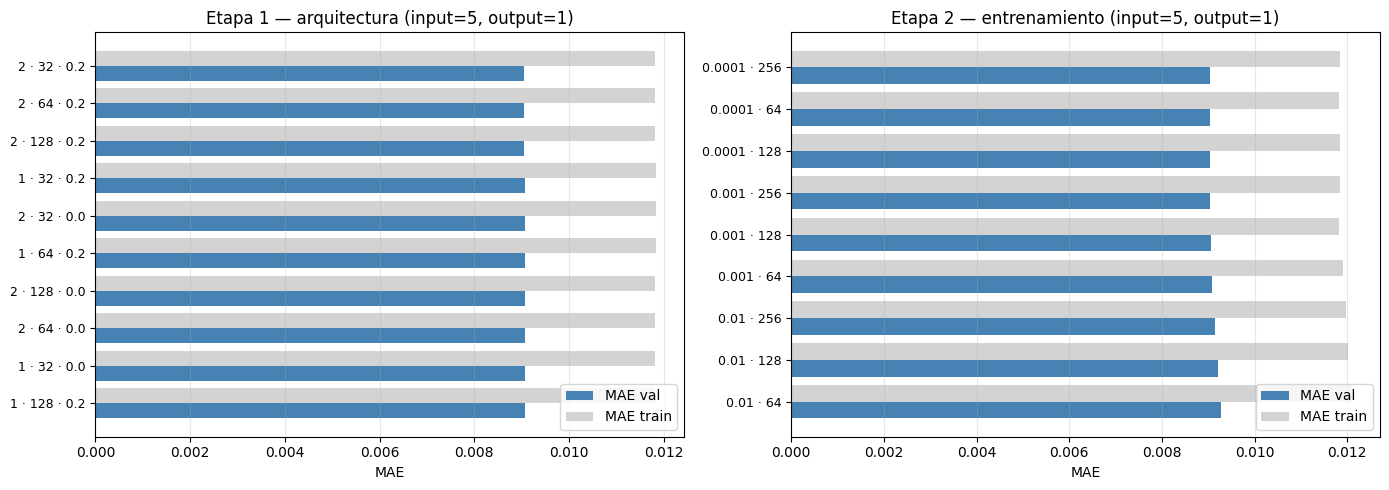

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_top(axes[0], results_arch_df,  ["gru_layers", "units", "dropout"],
         f"Etapa 1 — arquitectura (input={INPUT_W}, output={OUTPUT_W})")
plot_top(axes[1], results_train_df, ["learning_rate", "batch_size"],
         f"Etapa 2 — entrenamiento (input={INPUT_W}, output={OUTPUT_W})")

plt.tight_layout()
plt.show()

## Retrain y evaluación final en test

Con los HPs ganadores entrenamos una última vez y evaluamos **por primera vez en test**. Comparamos contra:
- La GRU base del grid de ventanas para `(input=5, output=1)`.
- La regresión lineal para `(input=5, output=1)`.

In [8]:
best_train = results_train_df.iloc[0]
print("Configuración ganadora:")
print(f"  gru_layers    = {int(best_arch.gru_layers)}")
print(f"  units         = {int(best_arch.units)}")
print(f"  dropout       = {float(best_arch.dropout)}")
print(f"  learning_rate = {best_train.learning_rate:.0e}")
print(f"  batch_size    = {int(best_train.batch_size)}")

best_model = build_gru(
    int(best_arch.gru_layers),
    int(best_arch.units),
    float(best_arch.dropout),
    lr=float(best_train.learning_rate),
)
mae_tr_best, mae_val_best, mae_te_best, ep_best = fit_eval(
    best_model, batch_size=int(best_train.batch_size)
)

# Referencia GRU base del grid de ventanas para (input=5, output=1)
# Cargamos los resultados del grid del notebook principal si existen en MLflow
gru_grid_runs = mlflow.search_runs(
    filter_string=f'tags.mlflow.runName = "Red_Neuronal_Recurrente_GRU_input{INPUT_W}_output{OUTPUT_W}"'
)
if not gru_grid_runs.empty:
    gru_base_mae_test  = gru_grid_runs.iloc[0]["metrics.test_mae"]
    gru_base_mae_train = gru_grid_runs.iloc[0]["metrics.train_mae"]
else:
    gru_base_mae_test  = None
    gru_base_mae_train = None
    print("Aviso: no se encontró la run GRU base del grid en MLflow.")

# Benchmark regresión lineal
linreg_bench = load_benchmark("lr_benchmark")
linreg_row   = linreg_bench[
    (linreg_bench.input_window == INPUT_W) & (linreg_bench.output_window == OUTPUT_W)
].iloc[0]

run_name_tuned = f"{EXPERIMENT_NAME}_tuned_input{INPUT_W}_output{OUTPUT_W}"
existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name_tuned}"')
if not existing_runs.empty:
    mlflow.delete_run(existing_runs.iloc[0].run_id)

with mlflow.start_run(run_name=run_name_tuned):
    for epoch, (tl, vl) in enumerate(zip(ep_best.history["loss"], ep_best.history["val_loss"])):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss",   vl, step=epoch)

    fig_best = plot_training_curve(ep_best)
    mlflow.log_figure(fig_best, "plots/loss_curve.png")
    plt.close(fig_best)

    mlflow.log_param("model_type",         "GRU")
    mlflow.log_param("gru_layers",         int(best_arch.gru_layers))
    mlflow.log_param("units",              int(best_arch.units))
    mlflow.log_param("dropout",            float(best_arch.dropout))
    mlflow.log_param("learning_rate",      float(best_train.learning_rate))
    mlflow.log_param("batch_size",         int(best_train.batch_size))
    mlflow.log_param("input_window_size",  INPUT_W)
    mlflow.log_param("output_window_size", OUTPUT_W)
    mlflow.log_param("n_params",           best_model.count_params())
    mlflow.log_param("epochs",             len(ep_best.history["loss"]))
    mlflow.log_metric("train_mae",         mae_tr_best)
    mlflow.log_metric("val_mae",           mae_val_best)
    mlflow.log_metric("test_mae",          mae_te_best)
    mlflow.keras.log_model(best_model, name="gru_model")

rows = [
    {"modelo": "Regresión lineal",  "MAE_train": linreg_row.MAE_train, "MAE_test": linreg_row.MAE_test},
    {"modelo": "GRU tuneada",       "MAE_train": mae_tr_best,          "MAE_test": mae_te_best},
]
if gru_base_mae_test is not None:
    rows.insert(1, {"modelo": "GRU base (grid)", "MAE_train": gru_base_mae_train, "MAE_test": gru_base_mae_test})

summary = pd.DataFrame(rows)
summary["Δ vs lin.reg."] = summary["MAE_test"] - linreg_row.MAE_test
summary

Configuración ganadora:
  gru_layers    = 2
  units         = 32
  dropout       = 0.2
  learning_rate = 1e-04
  batch_size    = 256


2026/05/02 12:32:19 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


,modelo,MAE_train,MAE_test,Δ vs lin.reg.
0,Regresión lineal,0.011821,0.012384,0.000000
1,GRU base (grid),0.011827,0.012312,-0.000072
2,GRU tuneada,0.011837,0.012244,-0.000140


## Comparación con benchmark de regresión lineal

- `delta < 0` (azul): la GRU mejora al benchmark.
- `delta > 0` (rojo): la GRU empeora al benchmark.

,input_window,output_window,MAE_test,MAE_test_benchmark,delta,pct_delta
0,5,1,0.012244,0.012384,-0.00014,-1.130639


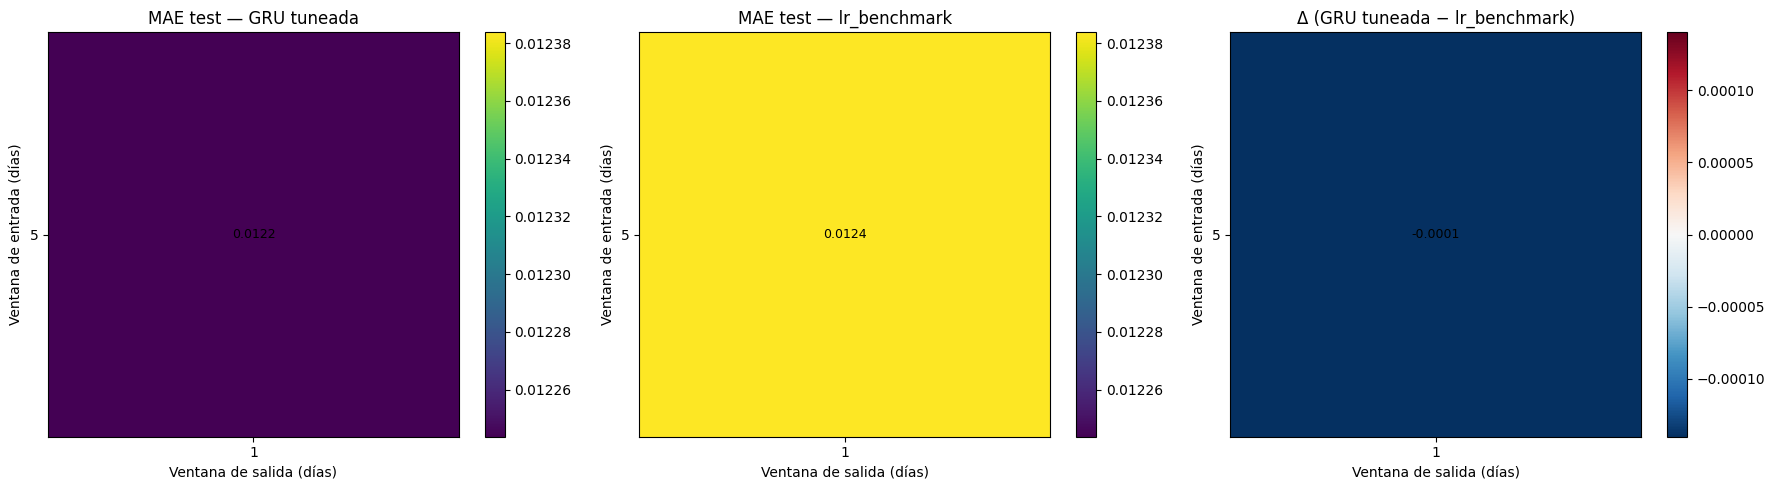

In [9]:
# Construimos un DataFrame con el formato que espera plot_benchmark_comparison
tuned_result = pd.DataFrame([{
    "input_window":  INPUT_W,
    "output_window": OUTPUT_W,
    "MAE_train":     mae_tr_best,
    "MAE_test":      mae_te_best,
}])

comparison = compare_to_benchmark(tuned_result, benchmark="lr_benchmark")
display(comparison)

plot_benchmark_comparison(tuned_result, benchmark="lr_benchmark", model_name="GRU tuneada")
plt.show()